In [1]:
import torch
import numpy as np
from training import train
from data_utils import make_dataset, load_dataset, fit_dset_to_m, make_grid_dataset
from controls import LQR
from tasks import stabilize_cartpole
from plotting import plot_trajectories, plot_experiment_new
from models import save_model, load_model
from experiments import save_experiment, load_experiment
import params
from IPython.display import HTML
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

######################
### DISPLAY CONFIG ###
######################
for name, values in vars(params).items():
    print(name, values)

torch.set_default_device("cuda")
#torch.set_default_device("cpu")

%load_ext autoreload
%autoreload 2

/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


__name__ params
__doc__ None
__package__ 
__loader__ <_frozen_importlib_external.SourceFileLoader object at 0x7f334420be90>
__spec__ ModuleSpec(name='params', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f334420be90>, origin='/home1/lutkus/latent_space/cartpole_lyapunov/params.py')
__file__ /home1/lutkus/latent_space/cartpole_lyapunov/params.py
__cached__ /home1/lutkus/latent_space/cartpole_lyapunov/__pycache__/params.cpython-313.pyc
__builtins__ {'__name__': 'builtins', '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.", '__package__': '', '__loader__': <class '_frozen_impor

In [2]:
################################
### Load or Generate Dataset ###
################################

#data = make_dataset(save=True, fname=params.dataset, render_mode=None, expert_controller=False)
#data = make_grid_dataset(params.grid_x_ranges, params.grid_u_ranges, params.grid_n_per_axis) # UNCOMMENT THIS TO MAKE DATASET
data = load_dataset(fname=params.dataset)
X, U, Xtest, Utest = data

/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/torch/utils/_device.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


In [ ]:
#####################################
### Run Experiment to Train Model ###
#####################################

from experiments import run_experiment_new

name = 'fwd_penalty_exp_new'
spec = {'symbols': [(0,1,2,3), (0, 1, 3), (1, 2, 3), (1, 3)],
        'ignored': [(), (2,), (0,), (0, 2)]}
n_runs = [1, 1, 1, 0]
exp=run_experiment_new(data, spec, plot=True, n_runs=n_runs, fname=name, save=True)

In [4]:
#######################
### Save Experiment ###
#######################

#save_name = name
#save_experiment(save_name, exp)

saving reduced_range.pkl


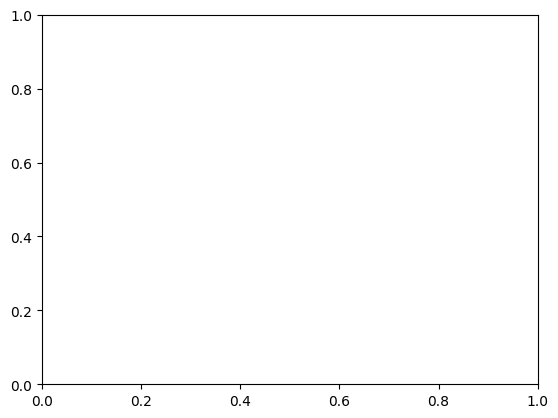

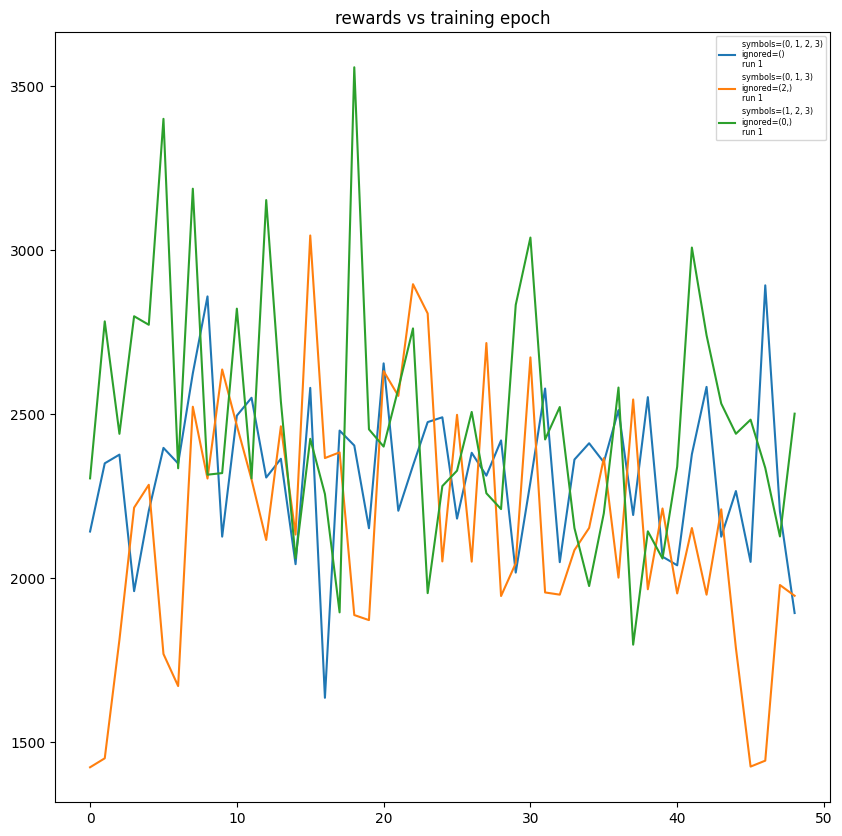

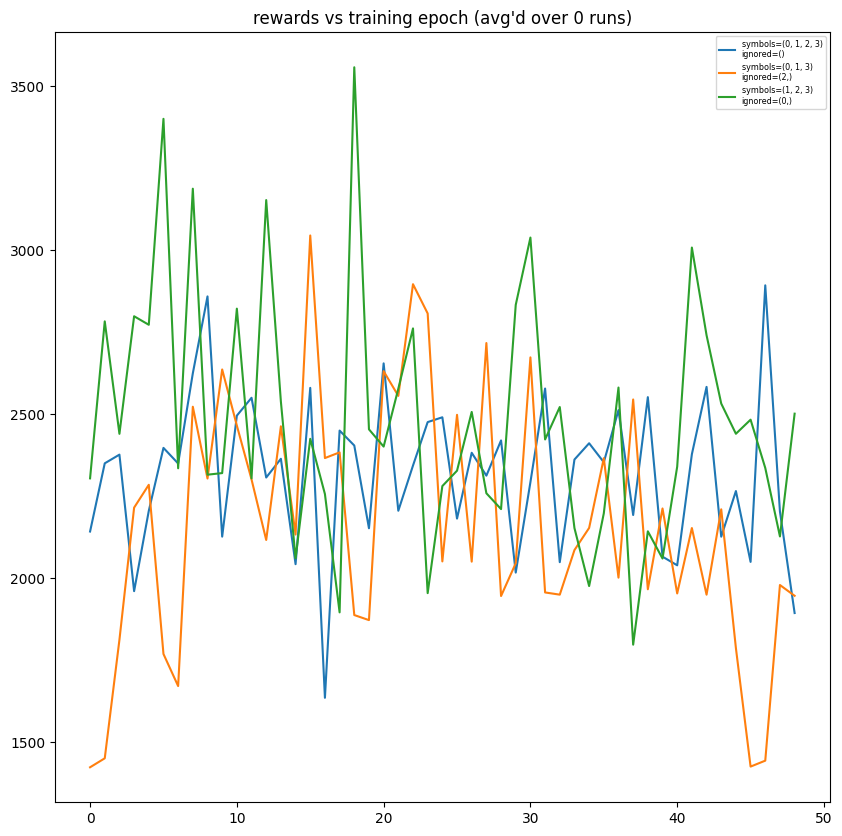

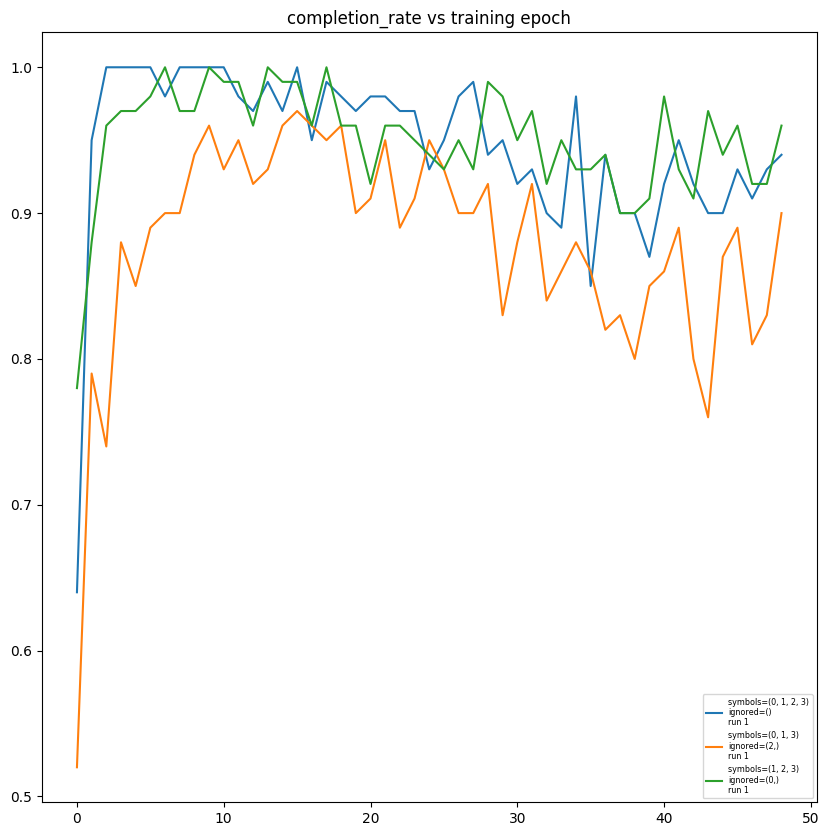

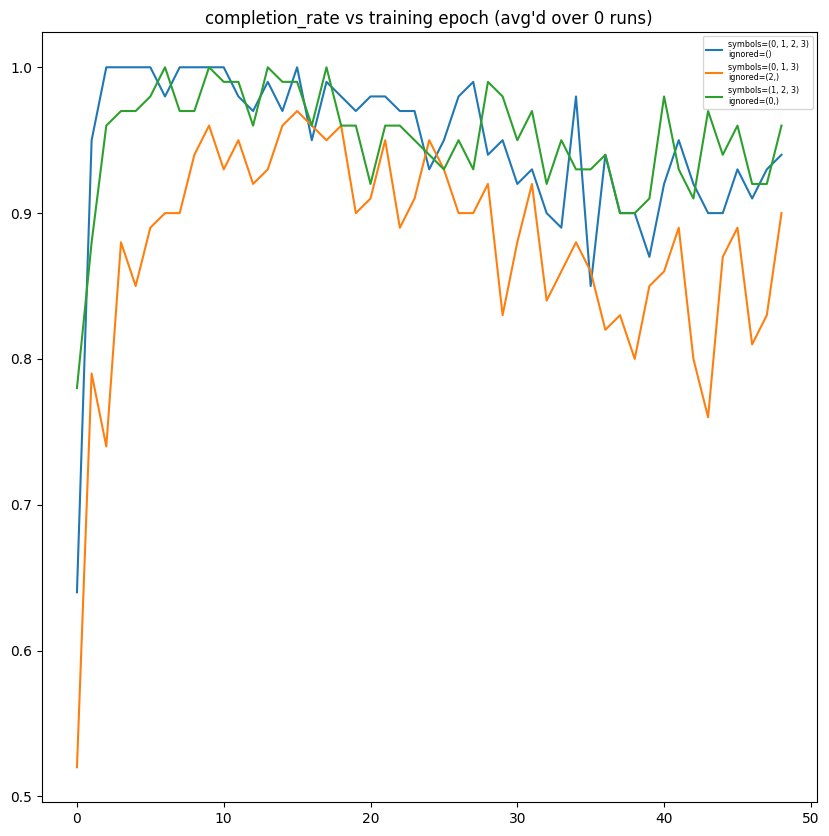

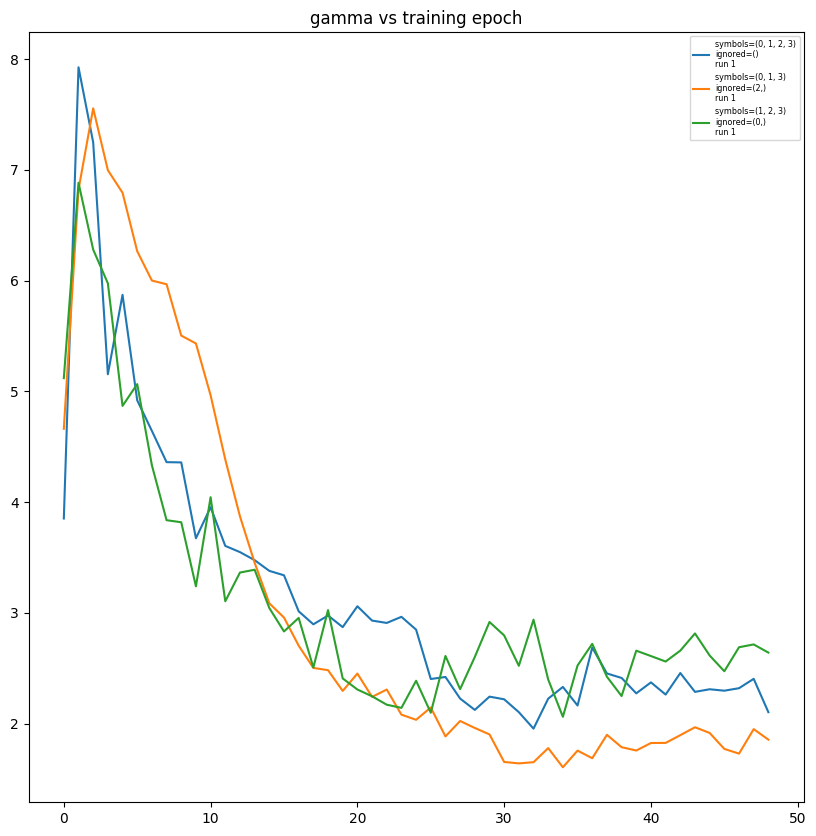

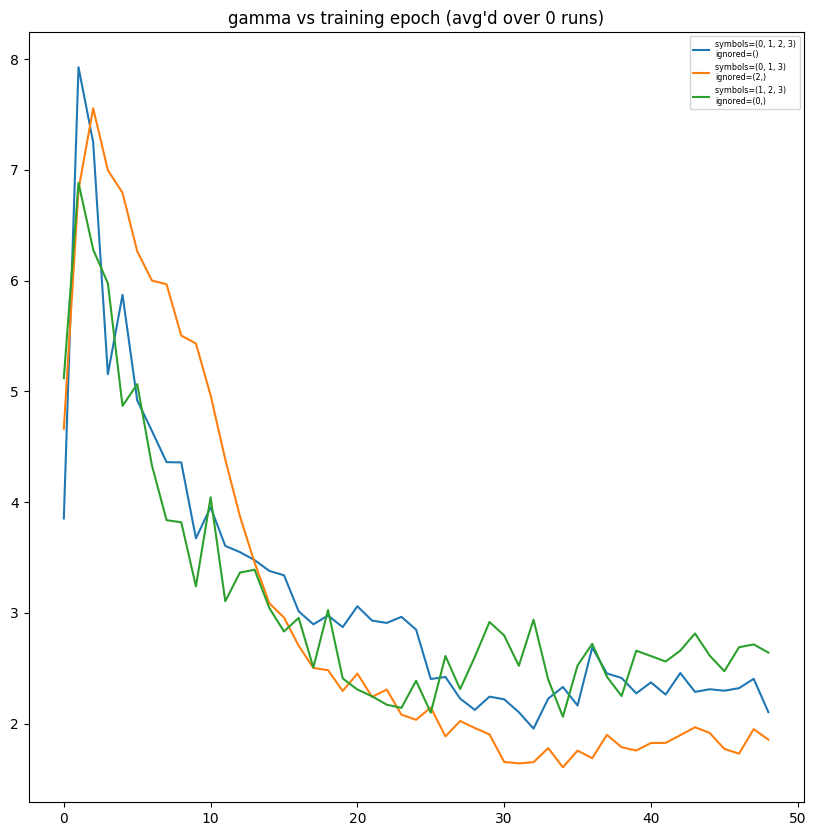

In [3]:
#######################
### Load Experiment ###
#######################

name = 'reference_model'
exp = load_experiment(name)
plot_experiment_new(exp)

In [4]:
###############################
### Choose Model Checkpoint ###
###############################

config_idx = 0
run_idx = 0

#best_model_idx = np.argmax(exp['completion_rate'][config_idx][1][run_idx])
#best_model_idx = np.argmin(exp['gamma'][config_idx][1][run_idx])
best_model_idx = -1

ae = exp['ae_list'][config_idx][1][run_idx][best_model_idx]
fdyn = exp['fdyn_list'][config_idx][1][run_idx][best_model_idx]
ae.encode(torch.tensor([0.,0.,0.,0.]))

tensor([ 0.0008, -0.0024], device='cuda:0', grad_fn=<ViewBackward0>)

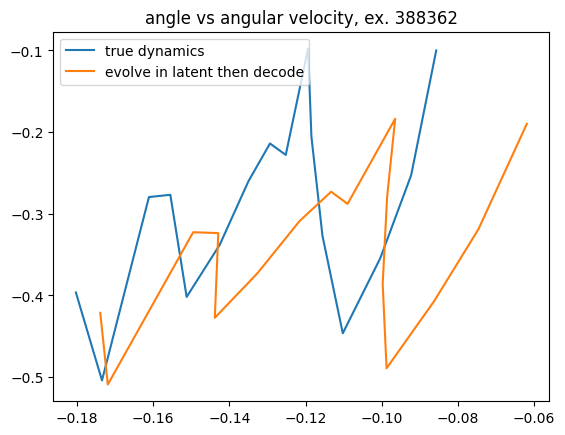

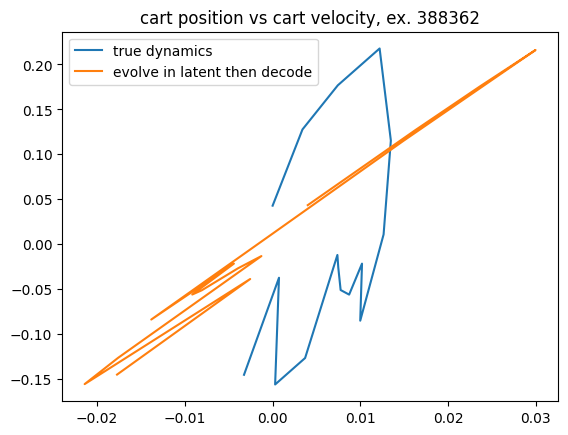

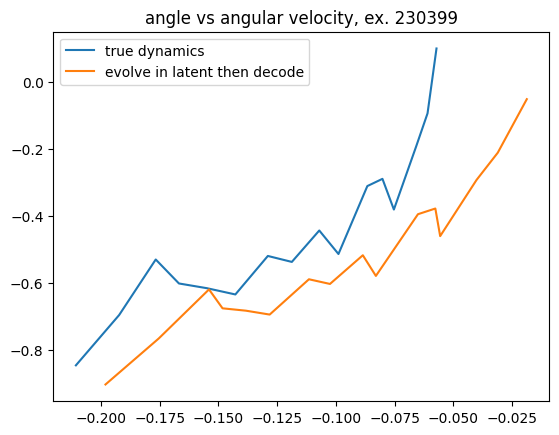

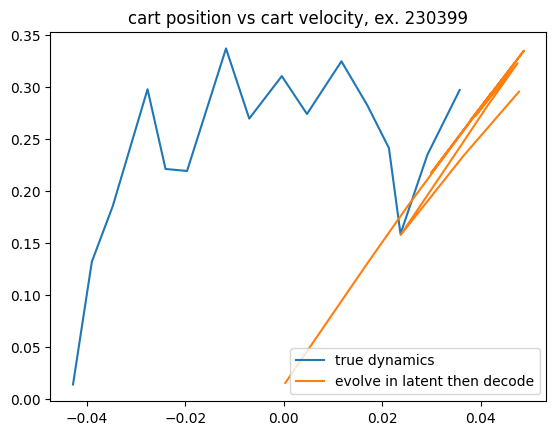

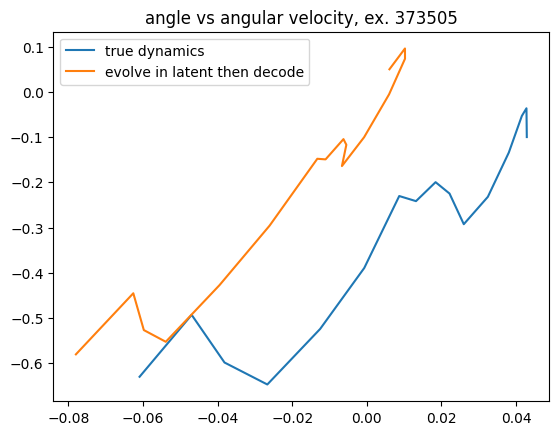

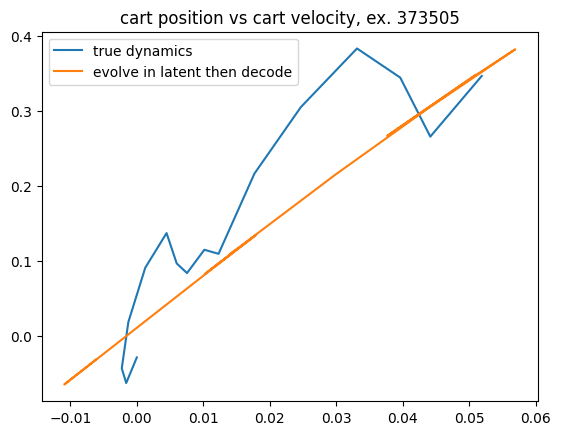

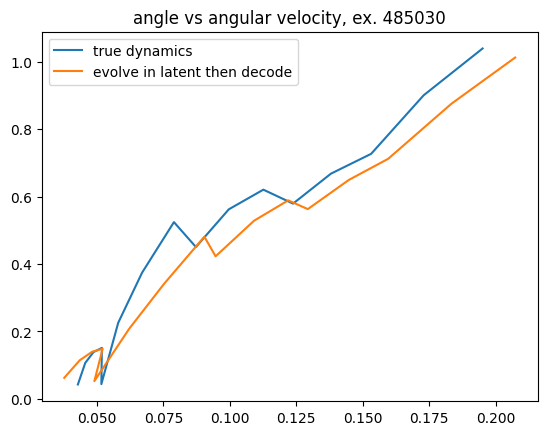

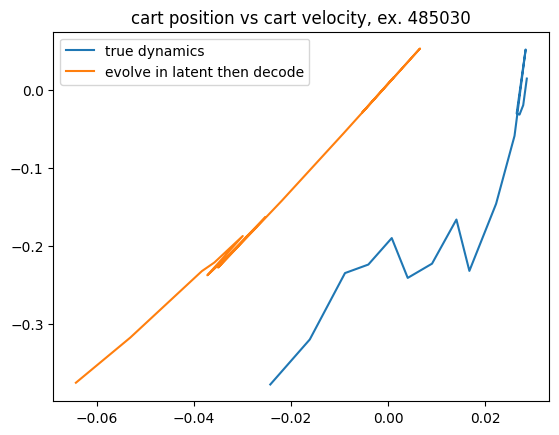

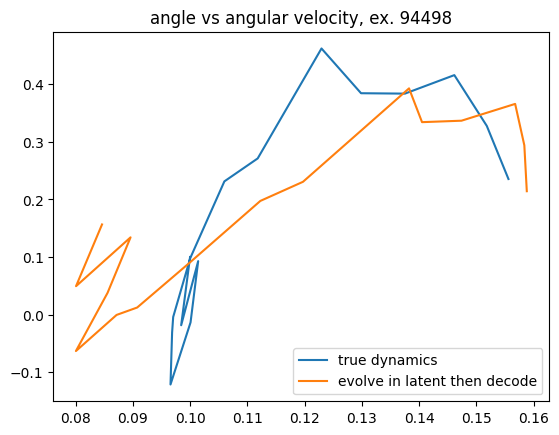

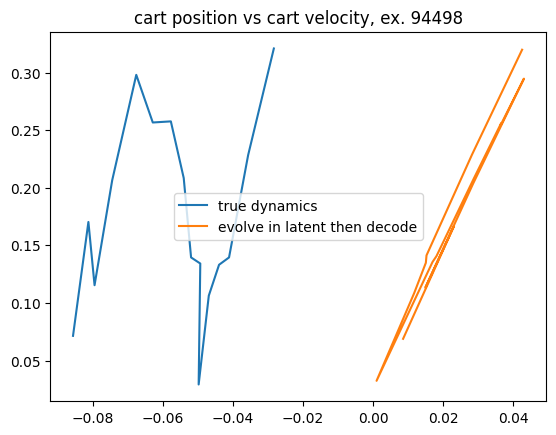

In [5]:
#######################################
### Plot Reconstructed Trajectories ###
#######################################

plot_trajectories(ae, fdyn, Xtest[0], Utest[0], 5, steps=params.traj_len)

z_eq tensor([[ 0.0008, -0.0024]], device='cuda:0', grad_fn=<AddmmBackward0>)


100%|██████████| 3000/3000 [06:01<00:00,  8.31it/s]


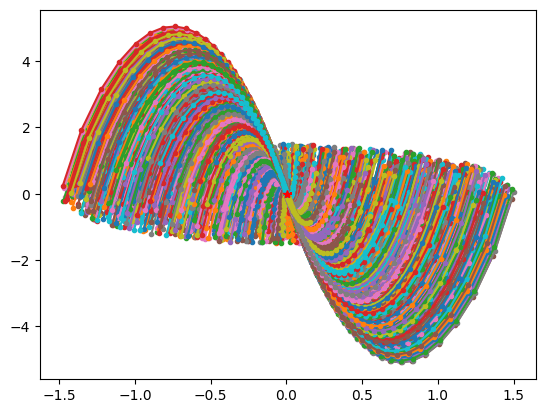

100%|██████████| 3000/3000 [05:24<00:00,  9.23it/s]


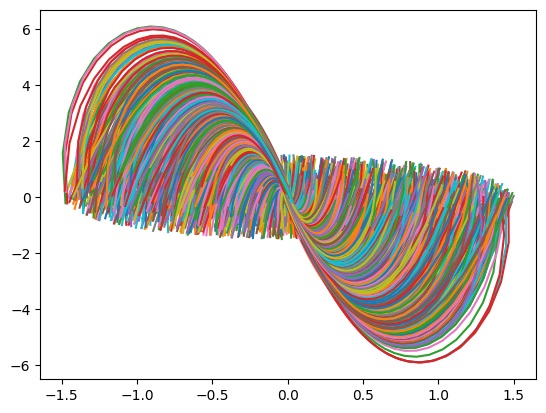

max x: 1.7539405371398742
max v: 1.1396860069069985
max theta: 0.6298250555992126
max w: 2.078218980541019


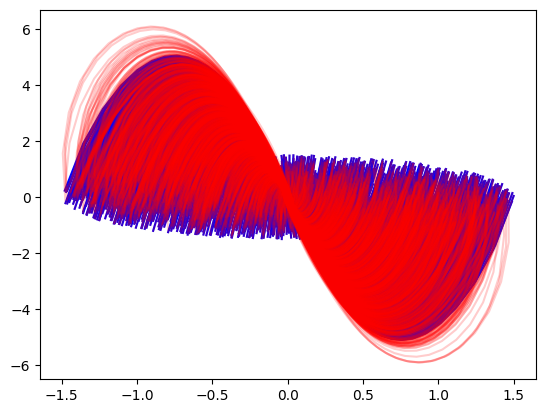

x data (3000, 301, 4)
z data (3000, 301, 2)
z proj data (3000, 301, 2)
u data (3000, 300, 1)
gamma forward 0.13886477
gamma backward 2.292798


In [6]:
####################################
### Initialize Data for Lyapunov ###
####################################

from plotting import plot_latent_trajectories
from utils import rollout_trajectories

r = 1.2e-1
r_test = r 
rz_init = 1.50 
n_traj = 3000 
T = 300
b = ae.encode(torch.tensor(4*[0.,])).cpu().detach().numpy()

for u_cost in [1]:
    lqr = LQR(ae, fdyn, u_cost=u_cost)
    pts, z_data, x_init_cond = plot_latent_trajectories(ae, fdyn, rz_init, n_traj, T=T, plot_quadratic=False, origin_spec=(b, r), lqr=lqr) #r=0.05
    x_data, z_proj_data, u_data, gammas = rollout_trajectories (ae, fdyn, lqr, x_init_cond, plot=True, n_traj=n_traj, T=T)
    gamma_fwd, gamma_bwd = gammas
    
    for zi in z_data:
        plt.plot(zi[:,0], zi[:,1], 'b-')
    for zi in z_proj_data:
        plt.plot(zi[:,0], zi[:,1], 'r-', alpha=0.2)
    plt.show()
    
    u_data = u_data[...,np.newaxis]
    
    print("x data", x_data.shape)
    print("z data", z_data.shape)
    print("z proj data", z_proj_data.shape)
    print("u data", u_data.shape)
    print("gamma forward", gamma_fwd)
    print("gamma backward", gamma_bwd) 

z_eq: tensor([ 0.0008, -0.0024], device='cuda:0', grad_fn=<ViewBackward0>)
pd loss: False
dyn loss: True
lb loss False
grad loss False
rho: 0.85
c lb 0.1
l_dyn 1
l_pd 1
l_lb 1
l_grad 1e-06
using grid data, grid_density: 100
features: 256
coeff: 0.1
LyapunovGeneral(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=256, bias=False)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=False)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=1, bias=False)
  )
)


/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


it 0: tensor([1381.2112], device='cuda:0', grad_fn=<AddBackward0>)
it 1000: tensor([0.0061], device='cuda:0', grad_fn=<AddBackward0>)
it 2000: tensor([0.0008], device='cuda:0', grad_fn=<AddBackward0>)
it 3000: tensor([0.0003], device='cuda:0', grad_fn=<AddBackward0>)
it 4000: tensor([9.2663e-05], device='cuda:0', grad_fn=<AddBackward0>)
it 5000: tensor([3.5498e-05], device='cuda:0', grad_fn=<AddBackward0>)
it 6000: tensor([1.2761e-05], device='cuda:0', grad_fn=<AddBackward0>)
it 7000: tensor([4.6366e-06], device='cuda:0', grad_fn=<AddBackward0>)
it 8000: tensor([1.6854e-06], device='cuda:0', grad_fn=<AddBackward0>)
it 9000: tensor([7.2657e-07], device='cuda:0', grad_fn=<AddBackward0>)
it 10000: tensor([3.7109e-07], device='cuda:0', grad_fn=<AddBackward0>)
it 11000: tensor([1.5736e-07], device='cuda:0', grad_fn=<AddBackward0>)
it 12000: tensor([6.7537e-08], device='cuda:0', grad_fn=<AddBackward0>)
it 13000: tensor([3.0450e-08], device='cuda:0', grad_fn=<AddBackward0>)
it 14000: tensor([

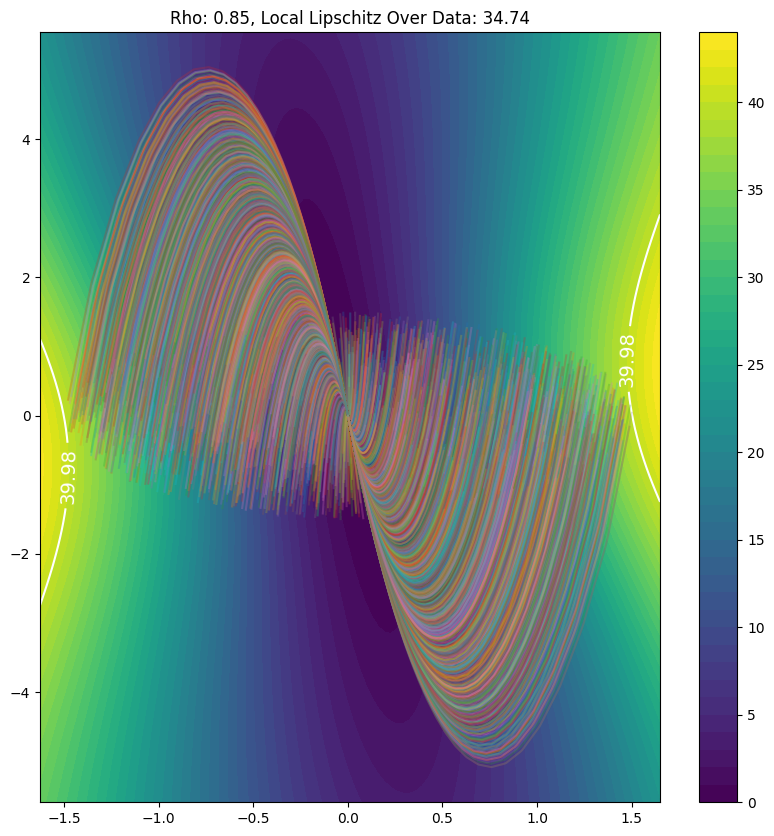

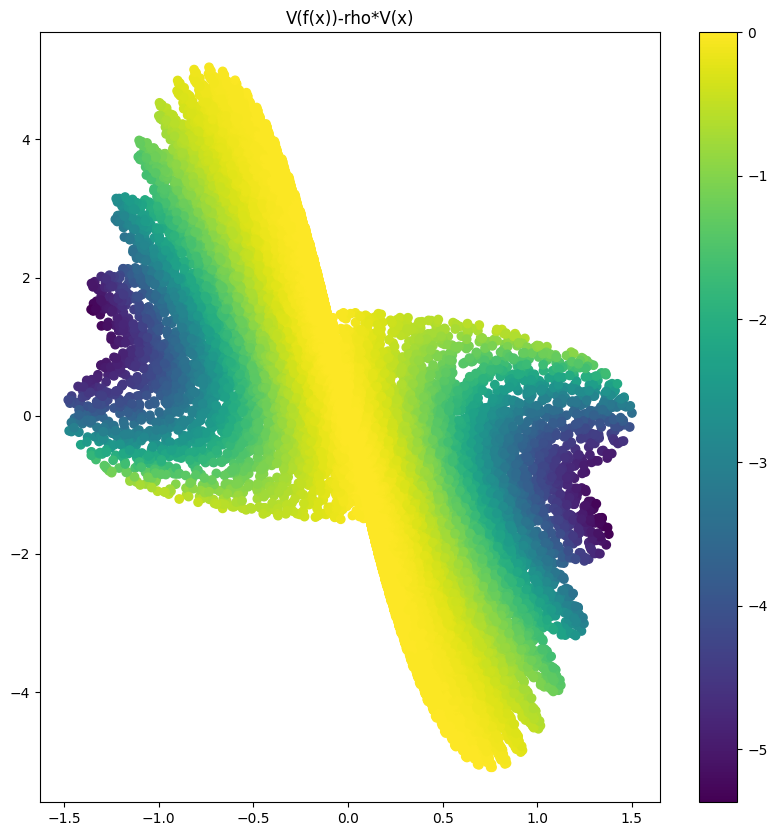

In [10]:
###############################
### Learn Lyapunov Function ###
###############################

from controls import mlp_lyapunov_reparam
from experiments import load_experiment
from theorem_tools import plot_violation

z_eq = ae.encode(torch.tensor([0.,0.,0.,0]).float())
print("z_eq:", z_eq)
rho = 0.85 
features = 256
parameterization = "general" 
V, rho, alpha, lip = mlp_lyapunov_reparam(z_data, epochs=int(3e4), lr=2e-4, grid_dens=100, rho=rho, z_eq=z_eq, parameterization=parameterization, features=256) #ep 0.5e4
plot_violation(V, rho, torch.tensor(z_data), ae, lip.item(), gamma_fwd, alpha/6, plot_contours=False)

100%|██████████| 14740/14740 [47:03<00:00,  5.22it/s] 


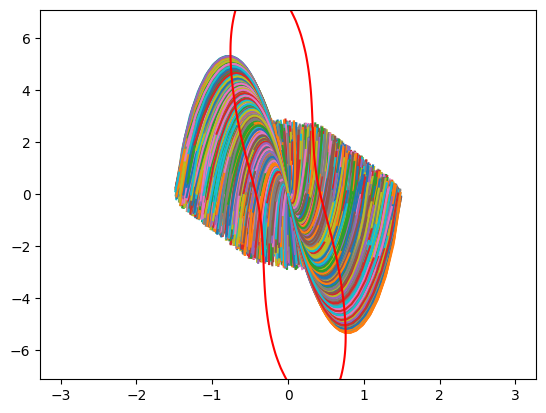

max x: 0.8217278057350235
max v: 0.9773102223669112
max theta: 0.3904914855957031
max w: 1.3920644309225565
(14740, 101, 4)


In [8]:
##############################################
### Compute Skeleton of Invariant Manifold ###
##############################################

from theorem_tools import compute_preimage, plot_lyapunov_lvlsets, verify_invariance

manifold_initial_conditions = compute_preimage(ae, z_data, 0.50, 14, uniform_sampling=True) 
a0_manifold = torch.max(V(ae.encode(torch.tensor(manifold_initial_conditions)))).cpu().item()

# n_traj doesn't do anything here, only the grid resolution in the previous step influences the number of trajecotries (one per each grid point)
manifold, _, _, _, _, _ = rollout_trajectories(ae, fdyn, lqr, manifold_initial_conditions, n_traj=500, T=100, V=V, a0=a0_manifold/6, n_per_axis=100)
print(manifold.shape)

In [9]:
############################################################
### Compute Preimage by Sampling from Invariant Manifold ###
############################################################

Dx = compute_preimage(ae, z_data, 0.75, 7, uniform_sampling=True, X=manifold, n_samples=int(4e4), eps=0.01) # n_samples=1e4, eps=0.01

(1997, 4)


100%|██████████| 250/250 [02:09<00:00,  1.92it/s]


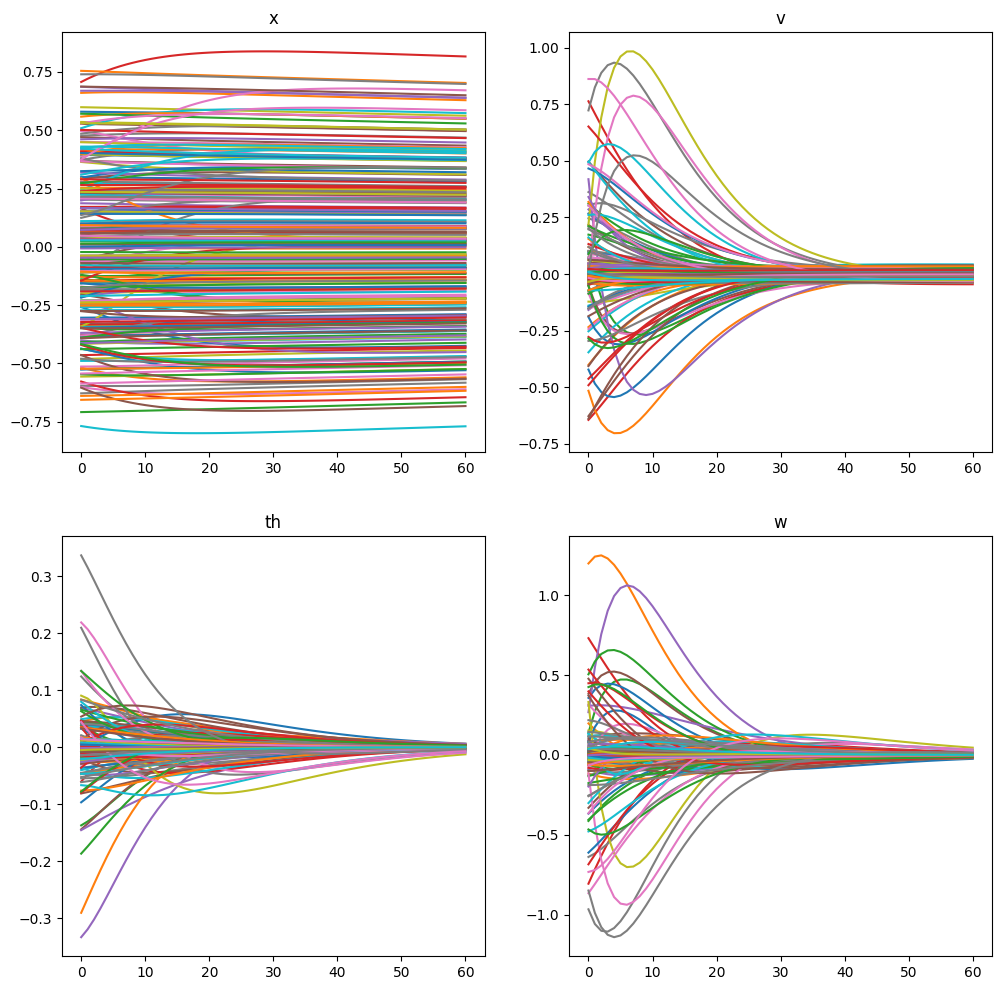

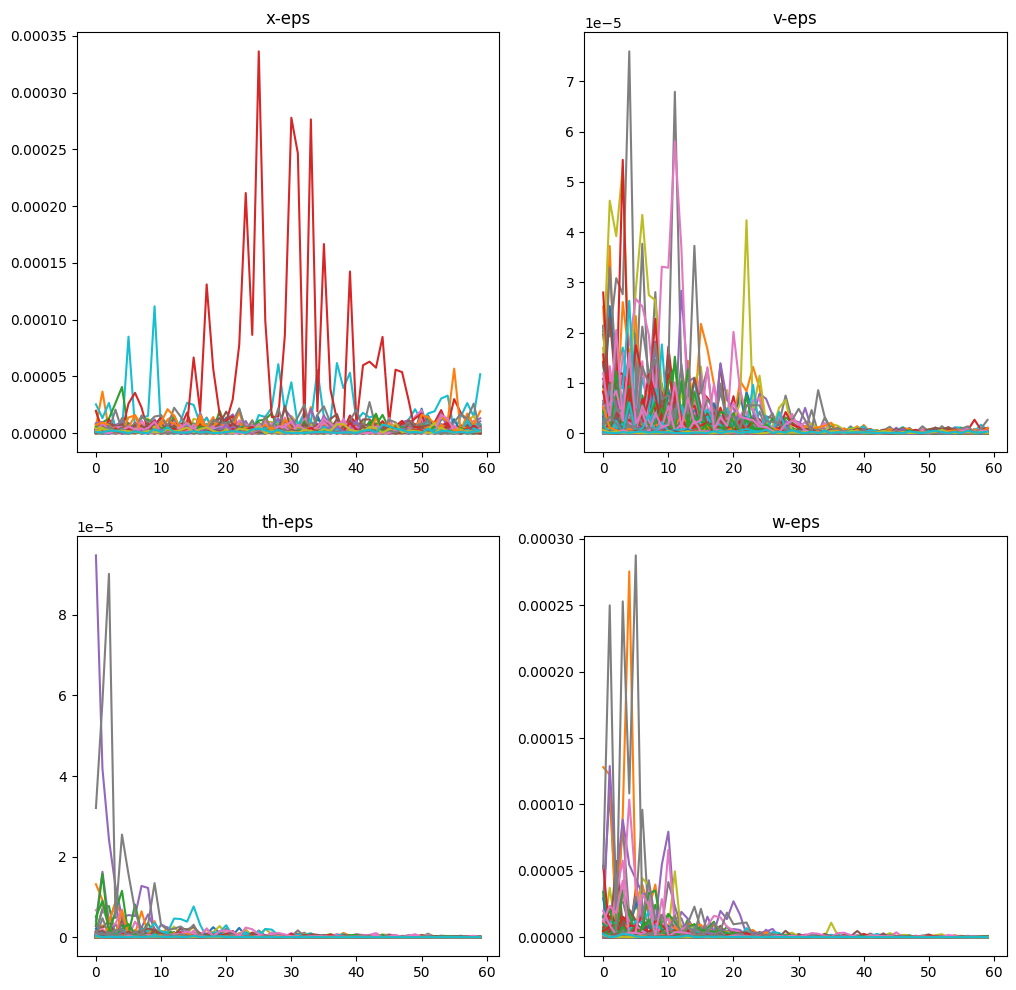

In [80]:
################################################
### Inspect Invariance of Invariant Manifold ###
################################################

print(Dx.shape)
_ = verify_invariance(ae, fdyn, T=60, stabilize=True, X0=Dx[0:250], manifold=manifold)

(39969, 4)
37.74119567871094


100%|██████████| 39059/39059 [3:55:56<00:00,  2.76it/s]   


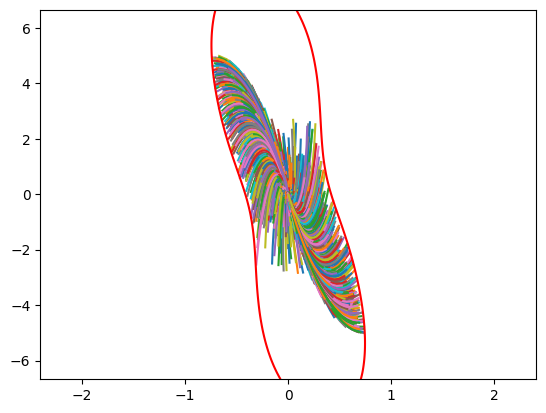

max x: 0.8163111209869385
max v: 0.8959404230117798
max theta: 0.29179614782333374
max w: 1.2385836839675903
gamma fwd: 0.019526644
L: 24.708900451660156
a0: 6.290199279785156
rho: 0.85
Ly/p: 3.2165458
R: 0.27667951583862305


100%|██████████| 39969/39969 [4:01:25<00:00,  2.76it/s]   


max x: 0.8163111209869385
max v: 0.9362109416401123
max theta: 0.3701718747615814
max w: 1.3987122847478792


/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


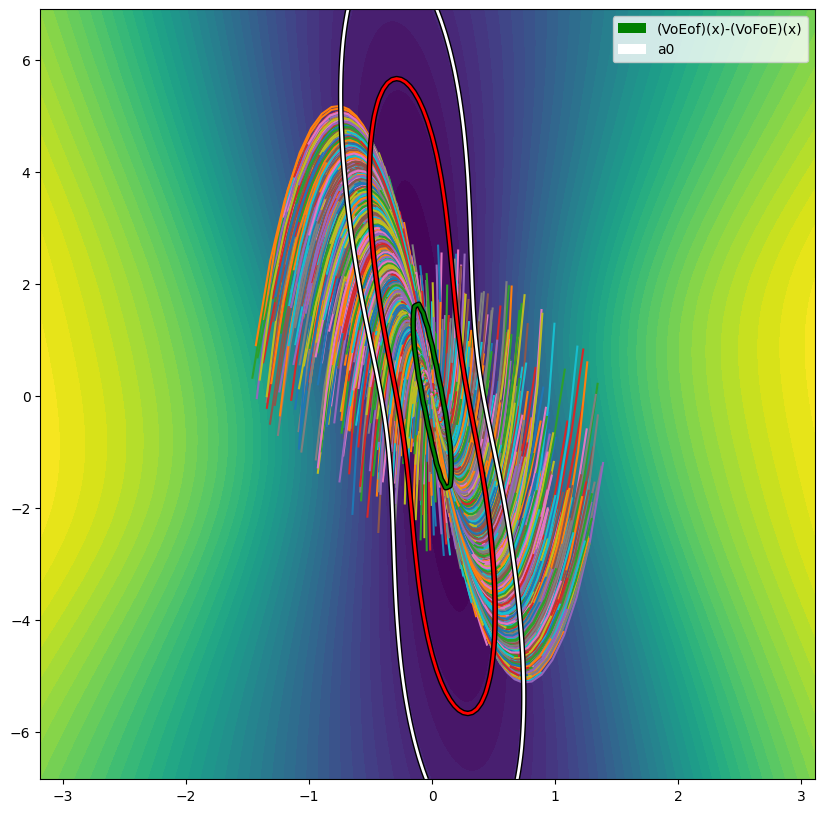

In [10]:
##################################################################
### Compute Ly/p and Levelsets over Trajectories from Preimage ###
##################################################################

a0 = torch.max(V(ae.encode(torch.tensor(Dx)))).cpu().item()
print(Dx.shape)
print(a0)
Dz = z_data
Dxtraj, gamma, L, res = plot_lyapunov_lvlsets(V, ae, fdyn, Dx, Dz, a0/6, rho, only_rollout=False, n_per_axis=175)

torch.Size([4997000])


/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


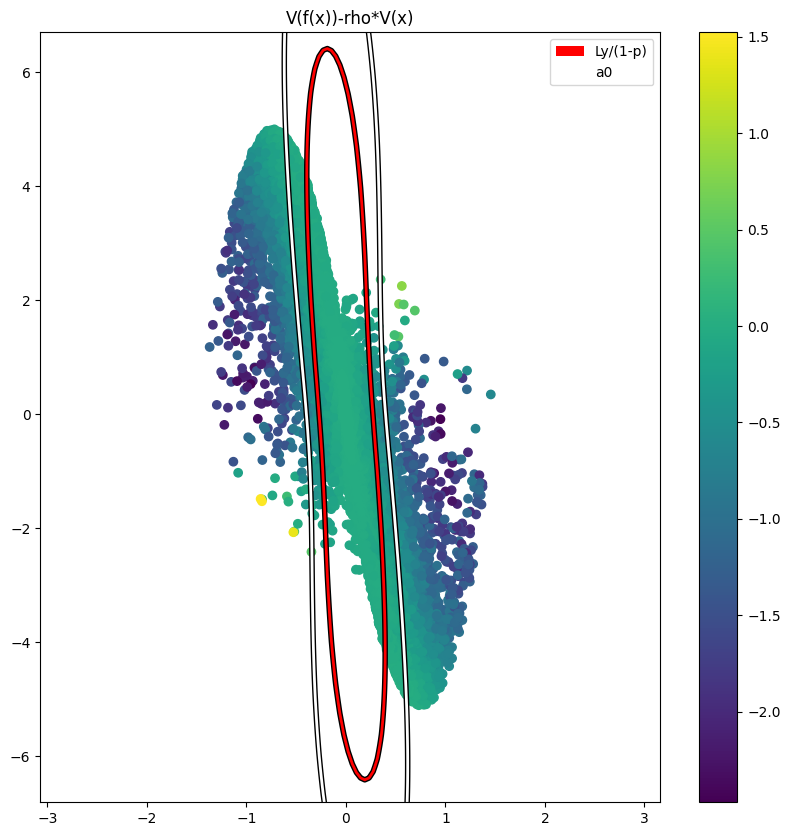

In [12]:
##################################################################
### Plot Violation of Lyapunov Condition for E(x) Trajectories ###
##################################################################

from theorem_tools import plot_violation, verify_invariance
plot_violation(V, rho, torch.tensor(Dxtraj), ae, gamma, L, a0/6)

100%|██████████| 4/4 [00:02<00:00,  1.49it/s]


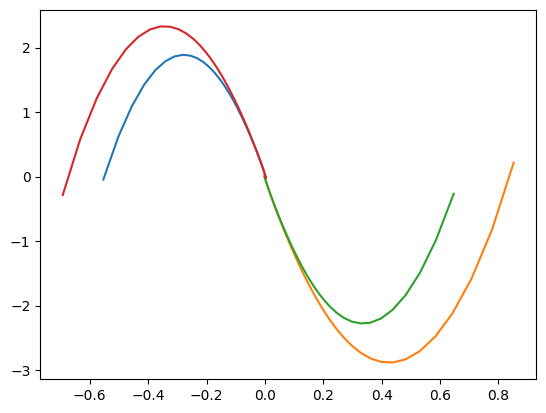

max x: 0.1745662849161878
max v: 0.5019988046979623
max theta: 0.15
max w: 0.6122166671863727
x-theta traj: (4, 2001, 4)


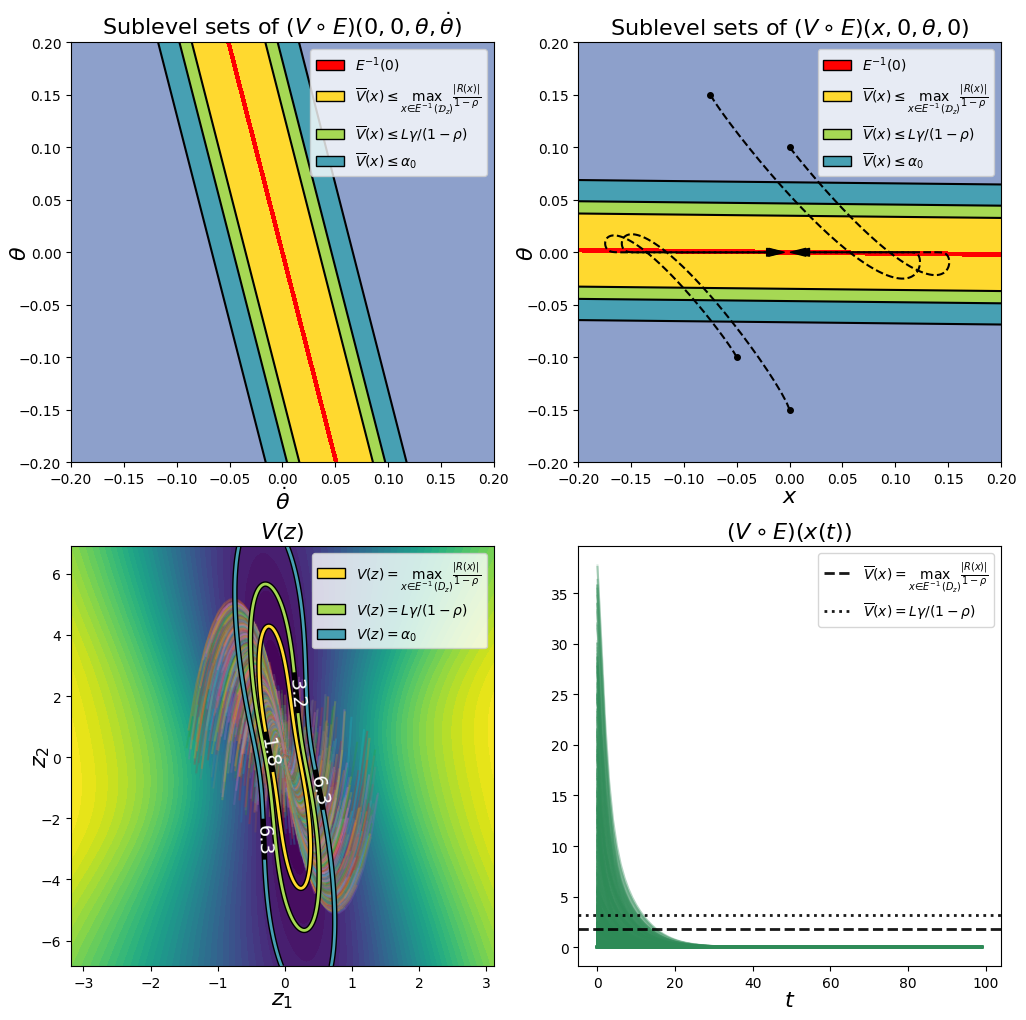

In [11]:
###################
### Make Figure ###
###################

from plotting import plot_lyapunov_slice
from theorem_tools import plot_figure_final
from utils import rollout_trajectories

lqr = LQR(ae, fdyn)

r_plot = 0.2 
X0_extra = np.array([[-0.05, 0.05, -0.1, 0.0],
                     [-0.075, -0.1, 0.15, 0.05],
                     [0.0, 0.0, 0.1, 0.0],
                     [0.0, 0.1, -0.15, 0.05]])
X_extra, _, _, _ = rollout_trajectories(ae, fdyn, lqr, X0_extra, T=2000)
plot_figure_final(V, ae, Dxtraj, 2*[r_plot], 2*[r_plot], res/(1-rho), a0/6, (L*gamma/(1-rho)).item(), n_per_axis=500, xth_traj=X_extra)